In [1]:
import pandas as pd
import numpy as np

df=pd.read_csv("cleaned_data.csv")

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9477 entries, 0 to 9476
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          9477 non-null   object 
 1   Customer_ID       9477 non-null   object 
 2   Order_Date        9477 non-null   object 
 3   Region            9477 non-null   object 
 4   City              9477 non-null   object 
 5   Sales_Channel     9477 non-null   object 
 6   Customer_Segment  9477 non-null   object 
 7   Age               9477 non-null   float64
 8   Category          9477 non-null   object 
 9   Subcategory       9477 non-null   object 
 10  Quantity          9477 non-null   int64  
 11  Unit_Price        9477 non-null   float64
 12  Total_Sales       9477 non-null   float64
 13  Cost              9477 non-null   float64
 14  Profit            9477 non-null   float64
 15  Payment_Method    9477 non-null   object 
 16  Satisfaction      9477 non-null   float64


In [4]:
orders=df.groupby("Region")['Order_ID'].count().sort_values()

print(orders)

Region
East       1684
West       1763
Central    1828
North      1910
South      2292
Name: Order_ID, dtype: int64


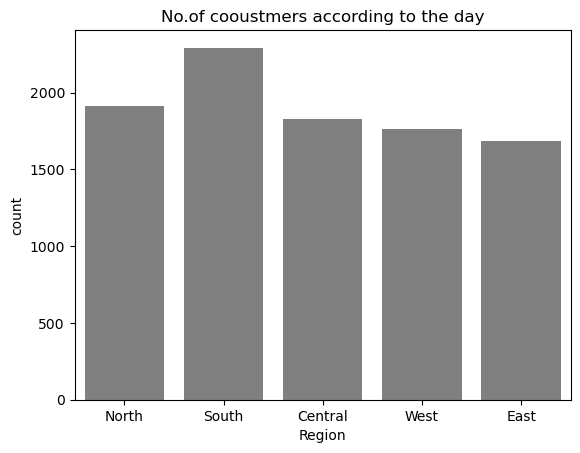

In [5]:
sns.countplot(data=df , x="Region",color='grey')

plt.title("No.of cooustmers according to the day")

plt.show()

In [6]:
df['Order_Date']=pd.to_datetime(df['Order_Date'],errors='coerce')

df['Quarter'] =  df['Order_Date'].dt.year.astype(str)+ '-' +  'Q' +df['Order_Date'].dt.quarter.astype(str)

quarterly_orders = df.groupby('Quarter')['Order_ID'].count().sort_index()

print(quarterly_orders)

Quarter
2022-Q1    655
2022-Q2    694
2022-Q3    710
2022-Q4    692
2023-Q1    657
2023-Q2    749
2023-Q3    715
2023-Q4    650
2024-Q1    696
2024-Q2    669
2024-Q3    679
2024-Q4    636
2025-Q1    619
2025-Q2    654
2025-Q3      1
2025-Q4      1
Name: Order_ID, dtype: int64


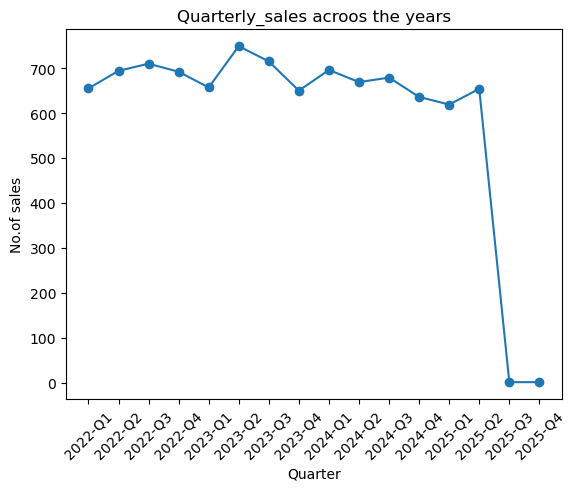

In [7]:
plt.plot(quarterly_orders.index, quarterly_orders.values , marker='o')

plt.title("Quarterly_sales acroos the years")

plt.xlabel("Quarter")

plt.ylabel("No.of sales")

plt.xticks(rotation= 45)

plt.show()

In [8]:
pd.set_option('display.float_format', '{:.2f}'.format)  # to change data from scientific notation

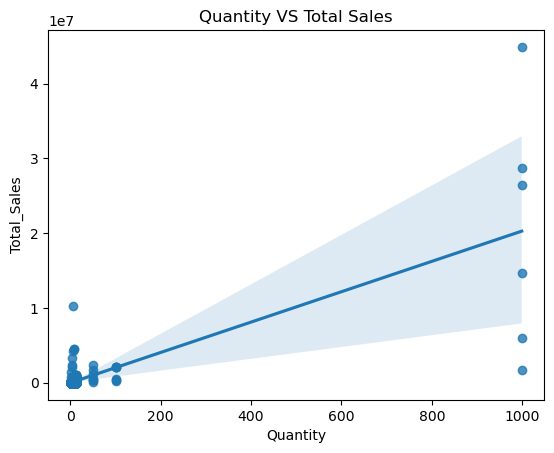

0.7850558118089137


In [9]:
sns.regplot(data=df, x='Quantity', y='Total_Sales')
plt.title("Quantity VS Total Sales")
plt.show()

print(df['Quantity'].corr(df['Total_Sales']))  # positive correaltion btw Quantity and Total_Sales

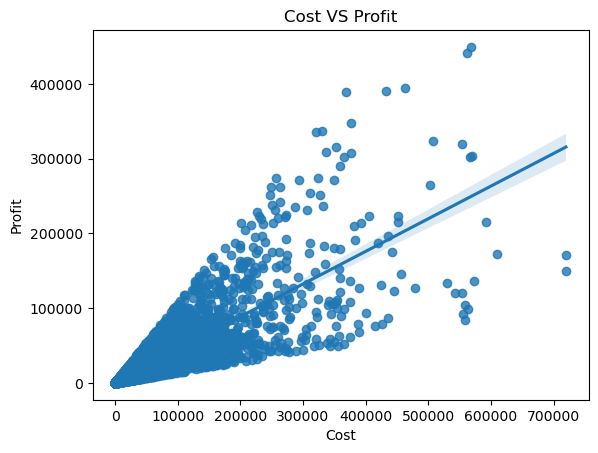

0.8383032014817599


In [10]:
sns.regplot(data=df, x='Cost', y='Profit')
plt.title("Cost VS Profit")
plt.show()

print(df['Cost'].corr(df['Profit']))

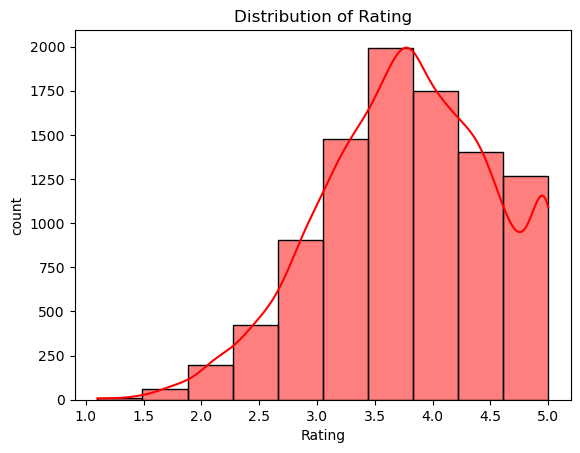

In [11]:
sns.histplot(data=df, x ='Satisfaction', kde=True ,bins=10,color='red')

plt.title("Distribution of Rating")
plt.xlabel("Rating")
plt.ylabel("count")

plt.show()

In [12]:
Category_sales = df.groupby('Category')['Total_Sales'].sum().sort_values()

print(Category_sales)

Category
Grocery             8820588.33
Office Supplies    11590708.45
Beauty             20180272.27
Clothing           27676180.01
Sports             41197326.37
Home Appliances   129104632.98
Furniture         141581456.22
Electronics       300256284.89
Name: Total_Sales, dtype: float64


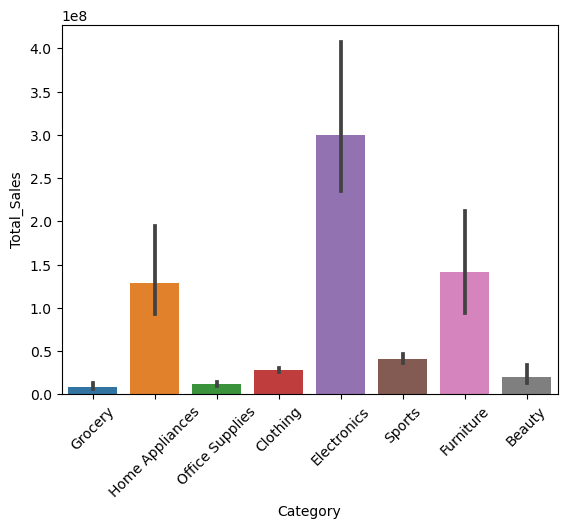

In [13]:
sns.barplot(data=df, x='Category', y='Total_Sales', estimator='sum')
plt.xticks(rotation=45)
plt.show()

             Total_Sales  Profit  Quantity
Total_Sales         1.00    0.14      0.79
Profit              0.14    1.00      0.04
Quantity            0.79    0.04      1.00


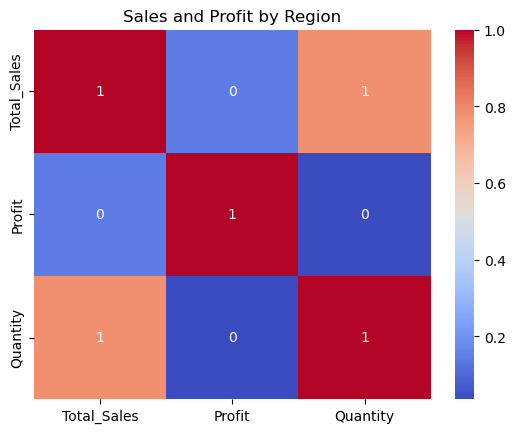

In [14]:
region_data = df[['Total_Sales', 'Profit','Quantity']].corr()

print(region_data)

sns.heatmap(region_data,annot=True,fmt='.0f',cmap='coolwarm')

plt.title('Sales and Profit by Region')

plt.show()

C:\Users\boddu\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


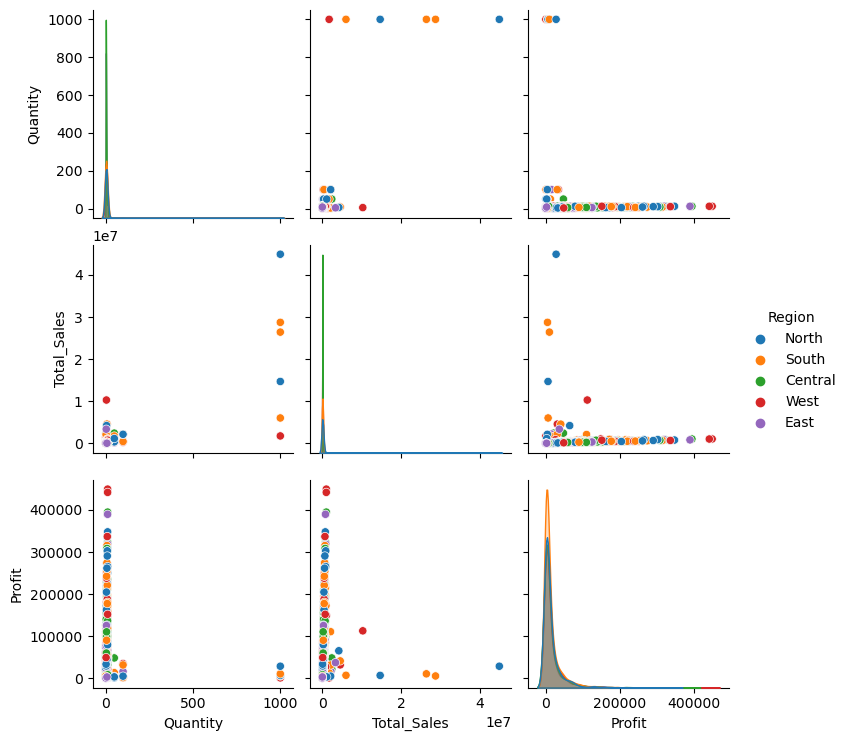

In [15]:
sns.pairplot(df, vars=['Quantity', 'Total_Sales', 'Profit'], hue='Region')

plt.show()

In [17]:
product_quantity = df.groupby("Category")["Quantity"].sum()

print(product_quantity)

Category
Beauty             4338
Clothing           4236
Electronics        7194
Furniture          5866
Grocery            6331
Home Appliances    5005
Office Supplies    5228
Sports             2960
Name: Quantity, dtype: int64


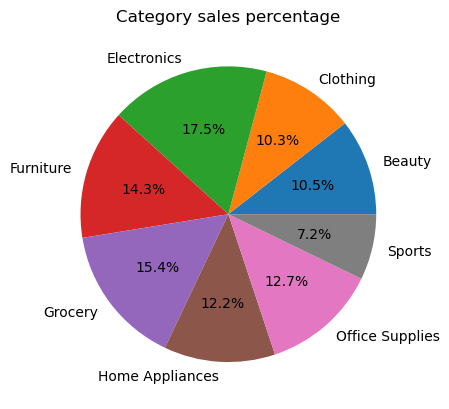

In [19]:
plt.pie(product_quantity,labels=product_quantity.index,autopct="%.1f%%",)
plt.title("Category sales percentage")
plt.show()